In [1]:
import graphics_template
import matplotlib.colors as colors
from ssh_chain_sq import *
import numpy as np
import matplotlib.pyplot as plt

In [12]:
N                = 3
gamma_zero       = 0.05
fock_photon      = 8
Omega_J          = 1.0
Chi_J            = 0.0
base_excitations = 1
k_states         = (4 * N - 1)
Omega_C   = 0.7
Chi_C     =  0.3

chain = PHOTONICChain(
    N = N,
    Omega_C= Omega_C,
    Chi_C= 0.3,
    omega_r= 0.13,
    gamma = gamma_zero,
    fock_photon= fock_photon,
    Omega_J= Omega_J,
    Chi_J=Chi_J,
    kerr= 0.0,
    PBC = False
)
Omega_resonator = 0.34
start = 0.1
end = 0.9
positions = np.linspace(start, end, 2 * N)

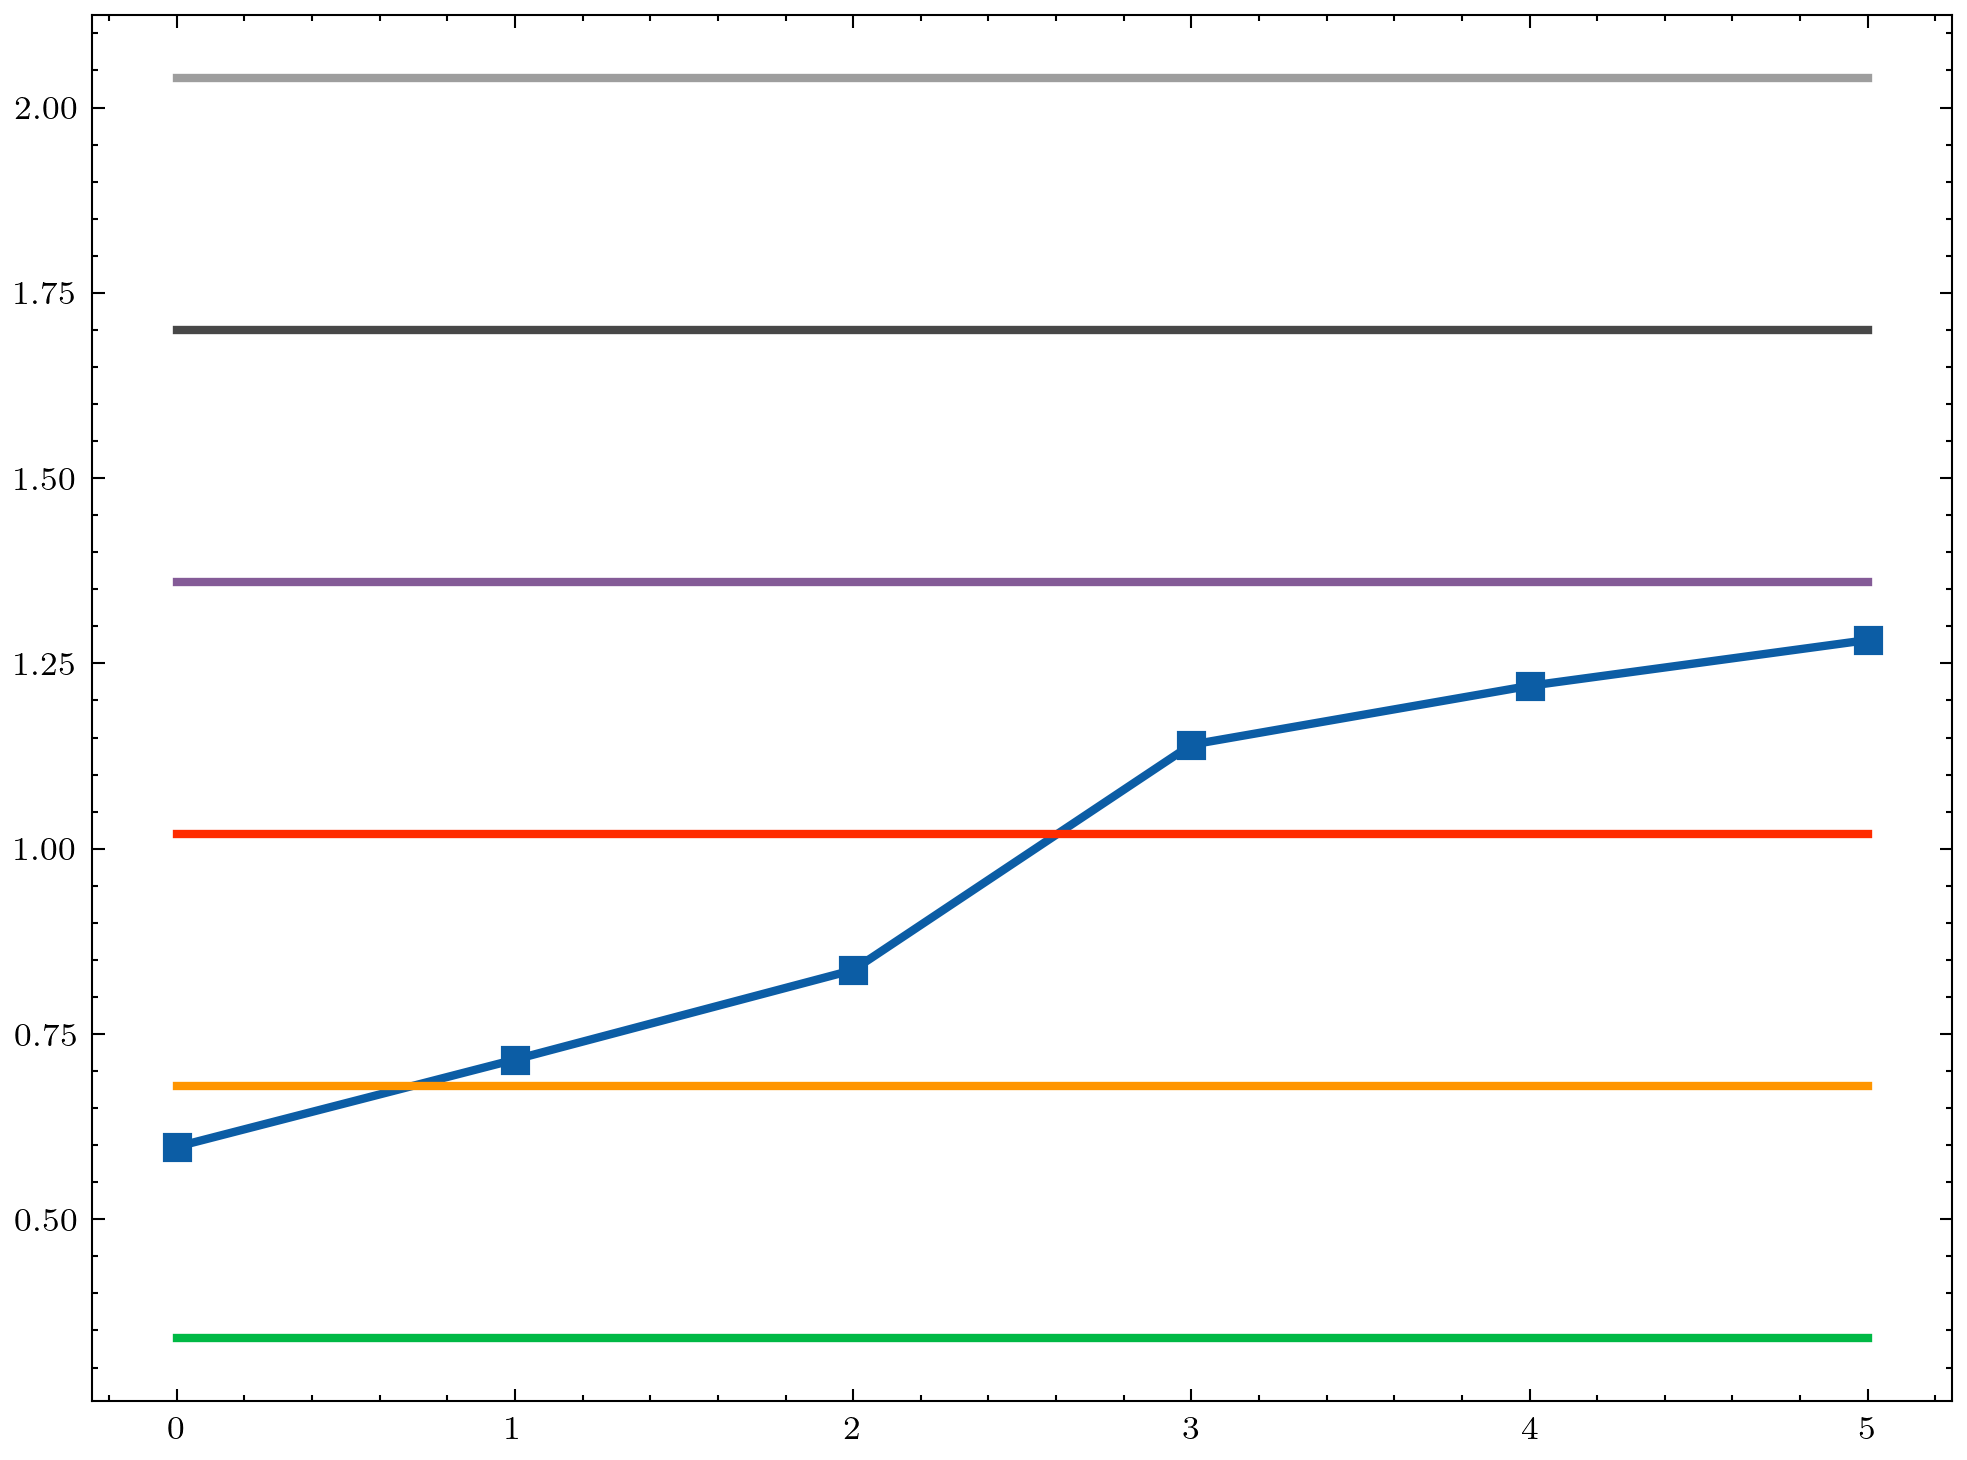

In [13]:
modes = chain.n
chain_energies = np.diag(2.0 * chain.H_C[:modes])
resonator_energies = (np.arange(modes) + 1) * Omega_resonator
plt.plot(chain_energies, linestyle = None, marker = 's')
plt.plot([0, modes-1], np.array([resonator_energies, resonator_energies]))

In [14]:
g0 = 0.0001
shift_matrix = chain.compute_common_bus_shift_matrix(
    Omega= Omega_resonator,
    positions= positions,
    g0 = g0,
    dispersive_tol= 0.01
)
coupling_matrix = chain.compute_common_bus_coupling_matrix(
    positions= positions,
    g0 = g0
)

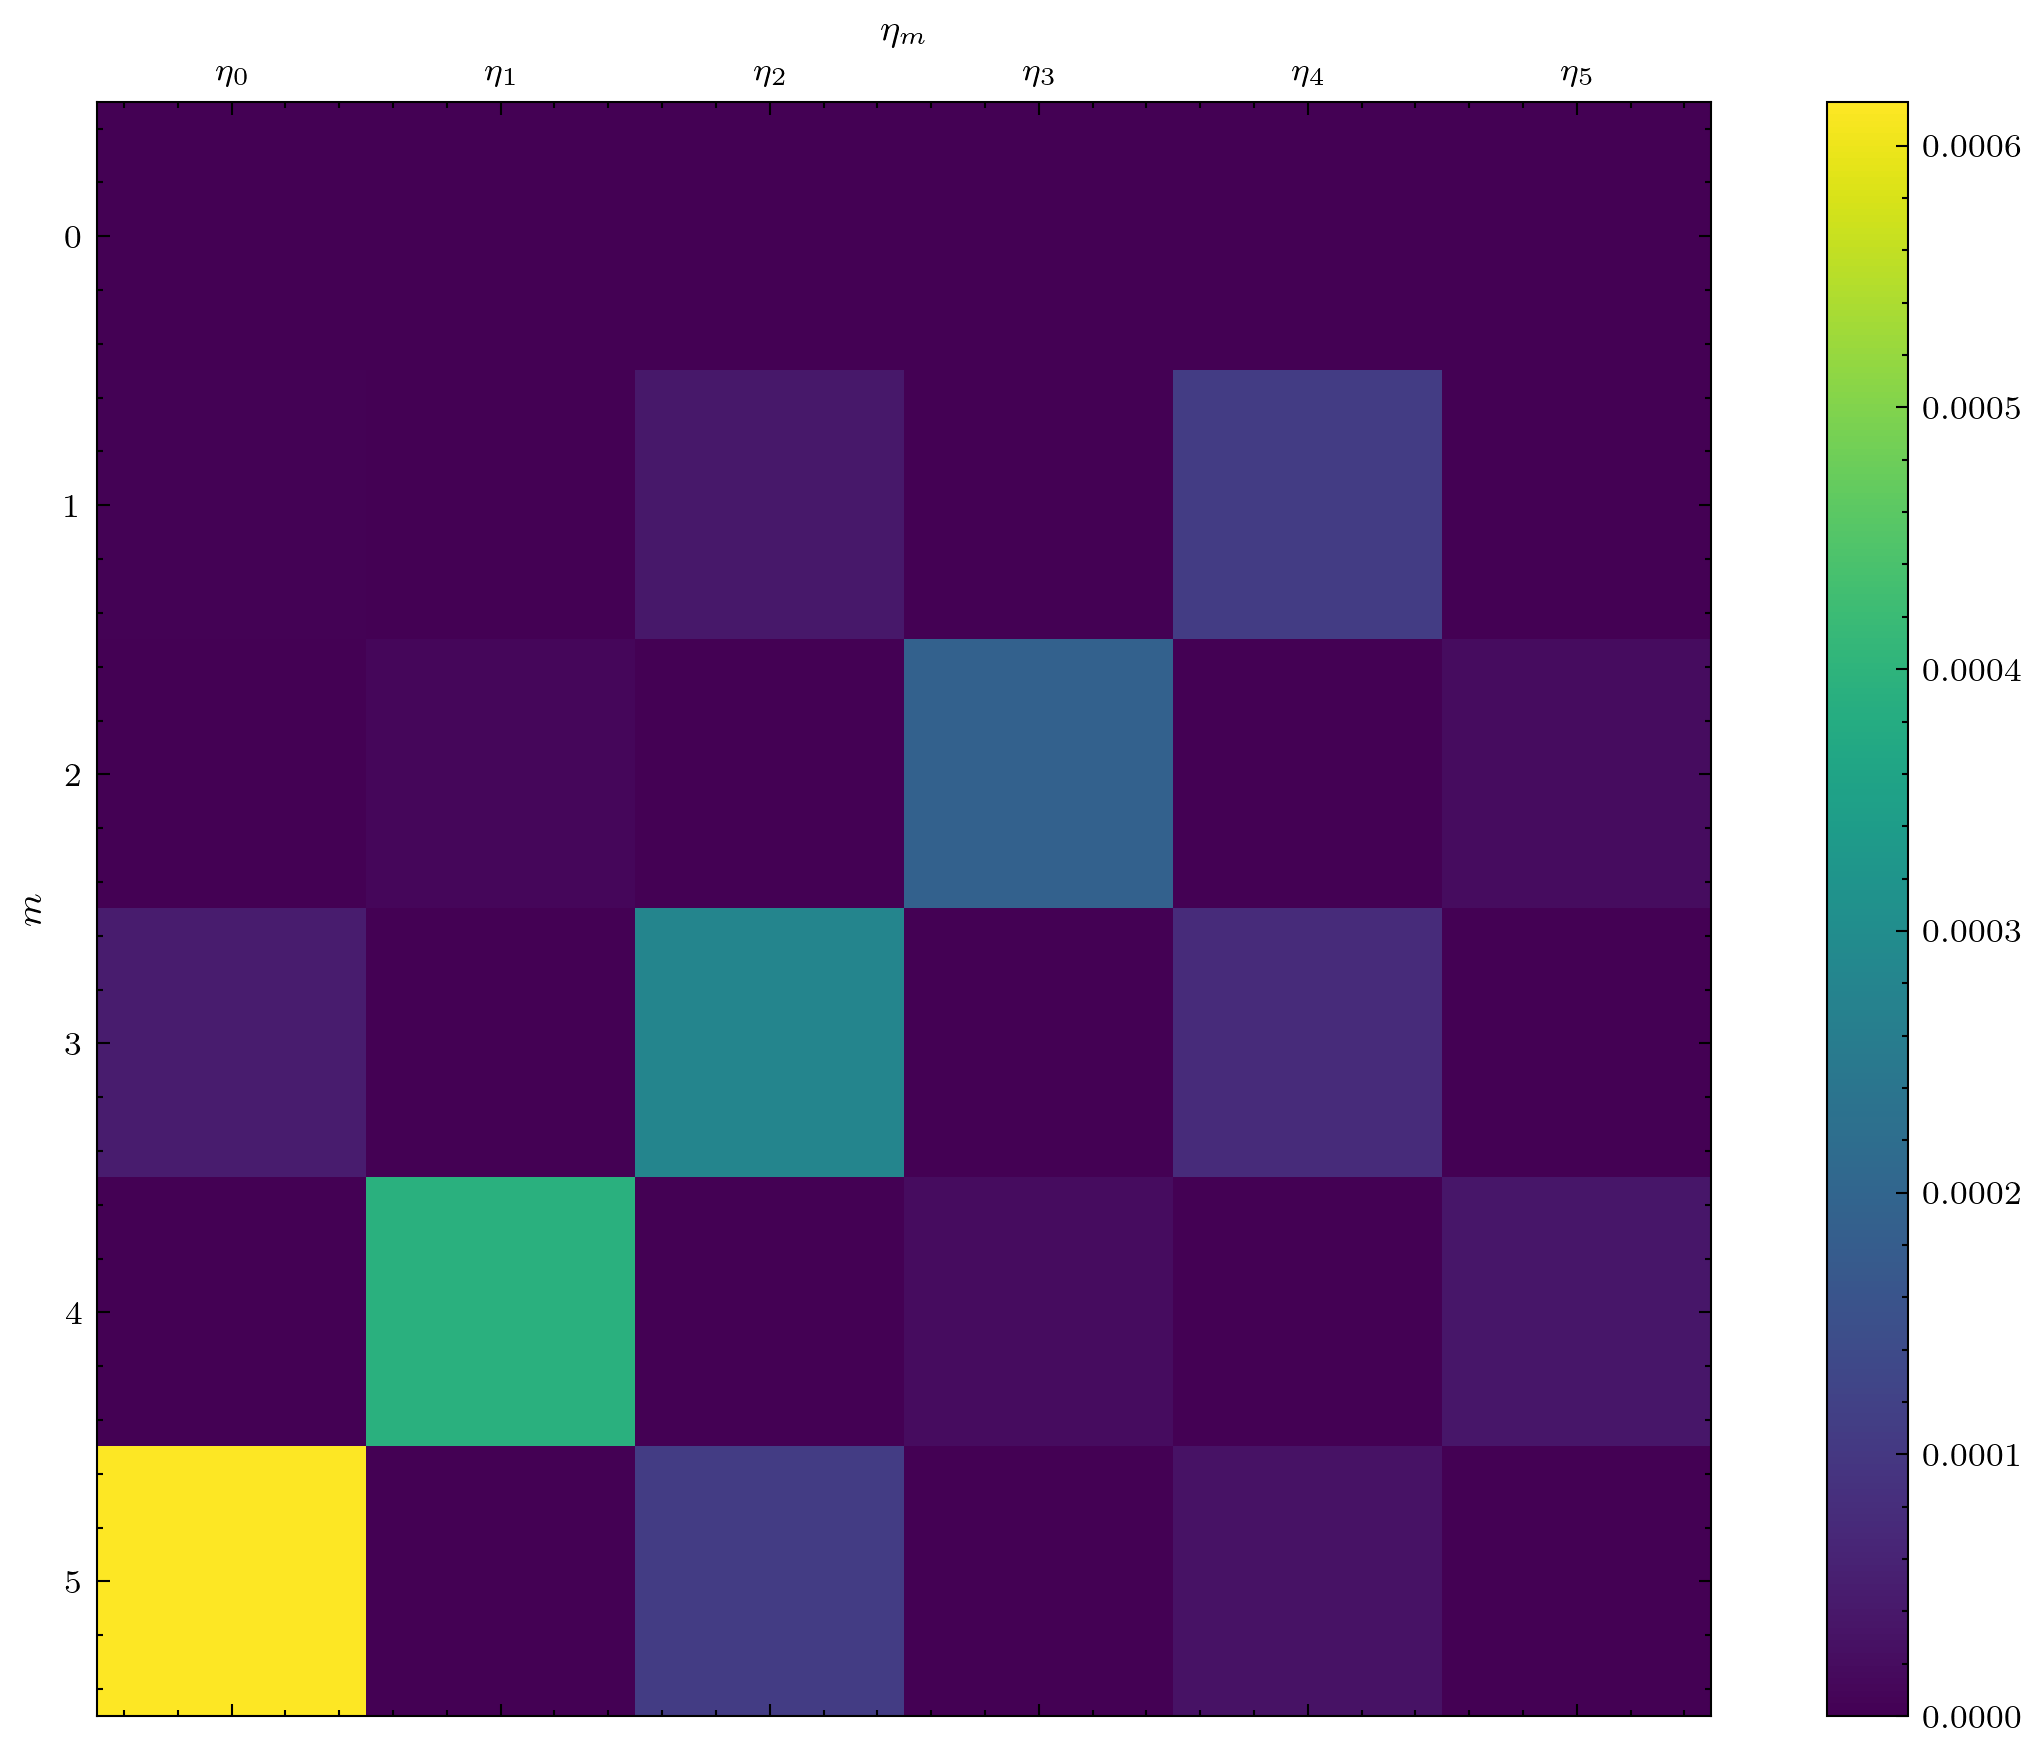

In [15]:


# shift_matrix assumed already computed via chain.compute_common_bus_shift_matrix(...)

fig, ax = plt.subplots()
im = ax.matshow(np.abs(coupling_matrix))
fig.colorbar(im, ax=ax)

n_rows, n_cols = coupling_matrix.shape

# Columns: eta_m (quasiparticle/Bogoliubov mode index), labeled on top to
# match matshow's default tick placement.
ax.set_xticks(range(n_cols))
ax.set_xticklabels([rf'$\eta_{{{m}}}$' for m in range(n_cols)])
ax.set_xlabel(r'$\eta_m$')
ax.xaxis.set_label_position('top')

# Rows: m (bus resonator mode index, 0 .. chain.n - 1)
ax.set_yticks(range(n_rows))
ax.set_yticklabels([str(m) for m in range(n_rows)])
ax.set_ylabel(r'$m$')

plt.tight_layout()
plt.show()

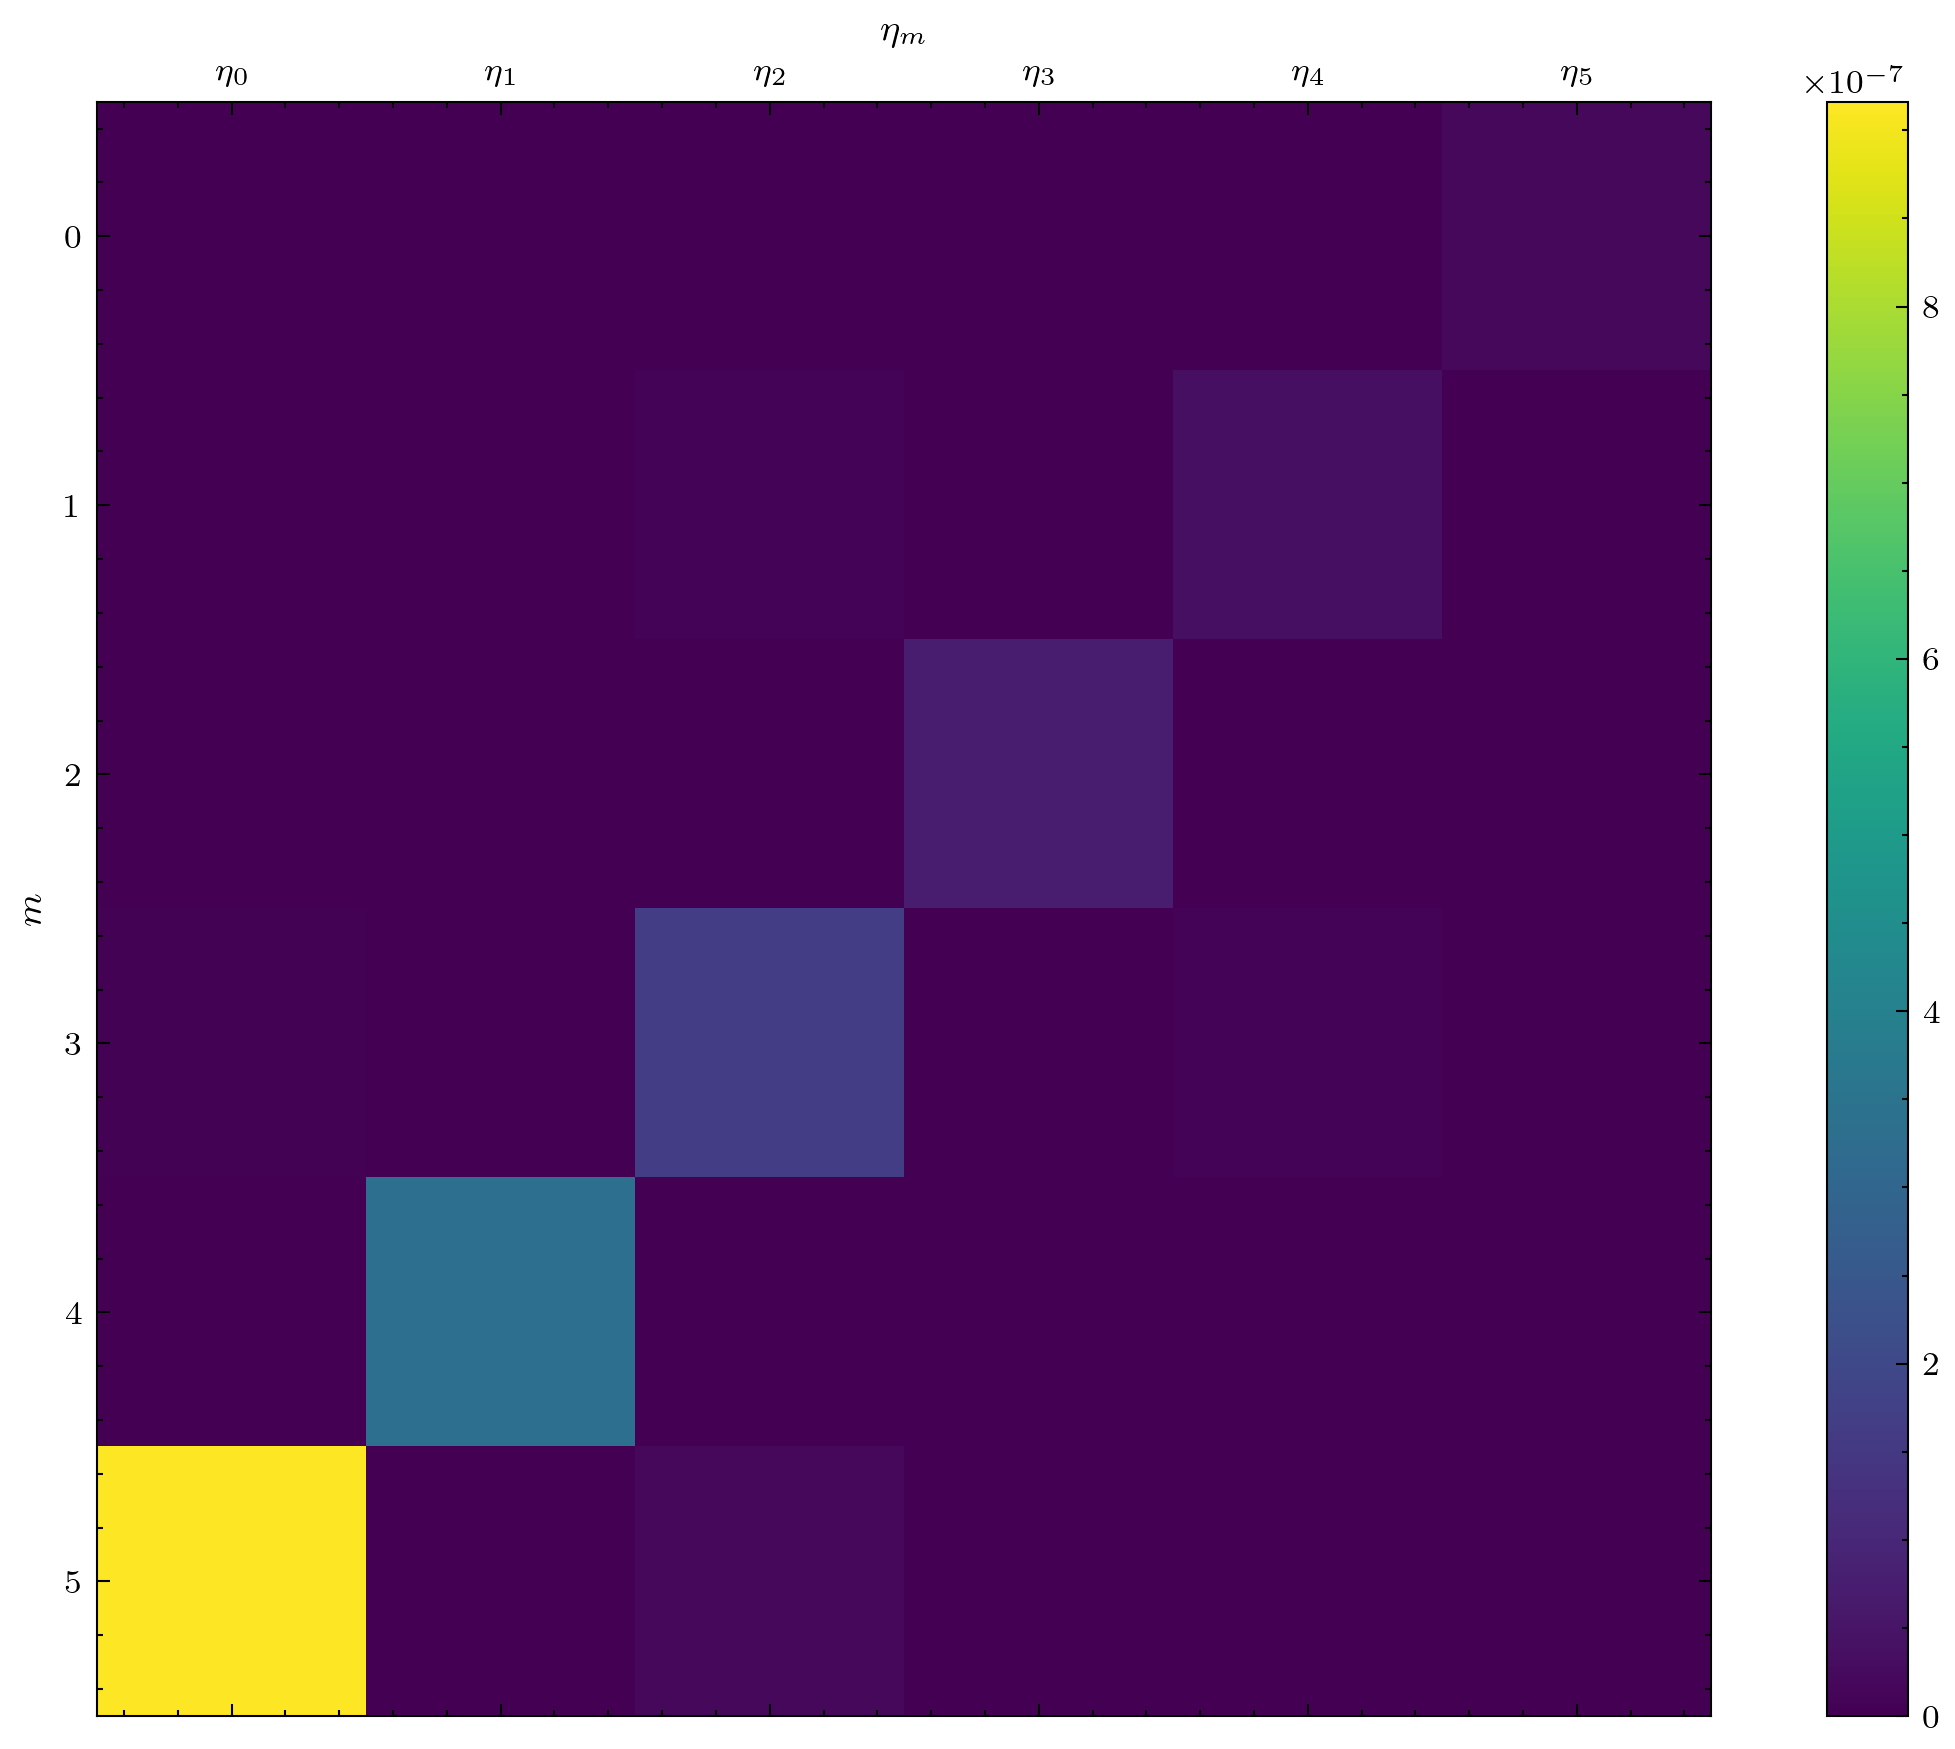

In [16]:


# shift_matrix assumed already computed via chain.compute_common_bus_shift_matrix(...)

fig, ax = plt.subplots()
im = ax.matshow(np.abs(shift_matrix))
fig.colorbar(im, ax=ax)

n_rows, n_cols = shift_matrix.shape

# Columns: eta_m (quasiparticle/Bogoliubov mode index), labeled on top to
# match matshow's default tick placement.
ax.set_xticks(range(n_cols))
ax.set_xticklabels([rf'$\eta_{{{m}}}$' for m in range(n_cols)])
ax.set_xlabel(r'$\eta_m$')
ax.xaxis.set_label_position('top')

# Rows: m (bus resonator mode index, 0 .. chain.n - 1)
ax.set_yticks(range(n_rows))
ax.set_yticklabels([str(m) for m in range(n_rows)])
ax.set_ylabel(r'$m$')

plt.tight_layout()
plt.show()